In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from Bayes_ST_QR.BSTQR import Spatiotemporal_Bayes_Quantile_regression

In [2]:
N = 365 * 3  # 3 years daily
t = np.arange(N)

# Simulated temperature (seasonal + noise)
y = 20 + 10*np.sin(2*np.pi*t/365) + np.random.normal(0, 2, N)


In [3]:
# STANDARDIZE
y_mean = y.mean()
y_std = y.std()
y_scaled = (y - y_mean) / y_std

# -----------------------------
# BUILD MODEL MATRICES
# -----------------------------

FF = np.vstack([
    np.ones(N),
    np.sin(2 * np.pi * t / 365),
    np.cos(2 * np.pi * t / 365)
])

GG = np.eye(3)

In [4]:
device1 = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [5]:
device1 = "cpu"

In [6]:
model = Spatiotemporal_Bayes_Quantile_regression(Y = y_scaled, F = FF.T, G = GG, Q = 0.5, device = device1)
model_upp = Spatiotemporal_Bayes_Quantile_regression(Y = y_scaled, F = FF.T, G = GG, Q = 0.95, device = device1)
model_lower = Spatiotemporal_Bayes_Quantile_regression(Y = y_scaled, F = FF.T, G = GG, Q = 0.05, device = device1)

100%|██████████| 4000/4000 [17:21<00:00,  3.84it/s]


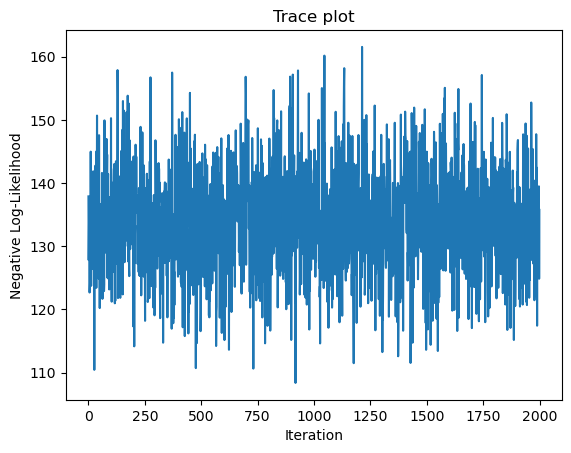

In [7]:
model.Gibbs_sampler()

100%|██████████| 4000/4000 [15:53<00:00,  4.19it/s]


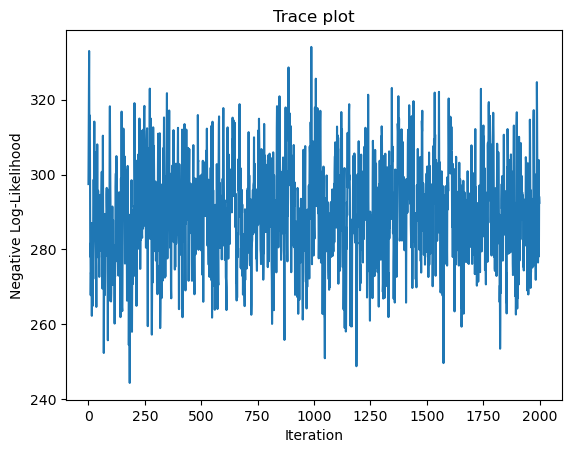

In [8]:
model_upp.Gibbs_sampler()

100%|██████████| 4000/4000 [15:49<00:00,  4.21it/s]


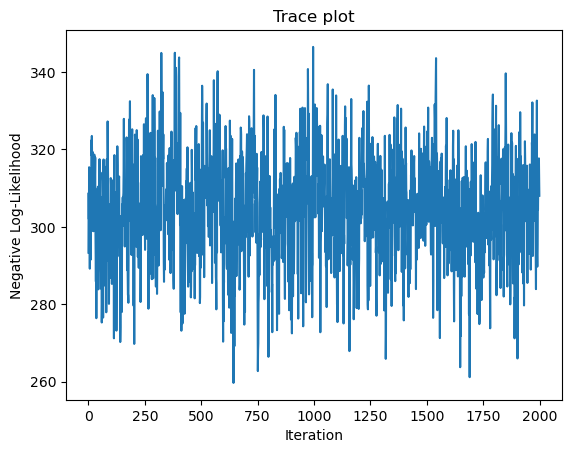

In [9]:
model_lower.Gibbs_sampler()

In [10]:
model.fit_Y()
model_upp.fit_Y()
model_lower.fit_Y()

In [11]:
# FORECAST 30 DAYS
H = 30
F_future = np.zeros((3, H))

for h in range(H):
    t_future = N + h
    # build future F_t (seasonality continues)
    F_future[:, h] = np.array([
        1,
        np.sin(2 * np.pi * t_future / 365), #hourly data: np.sin(2*np.pi*t/24) monthly: /12
        np.cos(2 * np.pi * t_future / 365)
    ])


In [12]:
Y_pred = model.predict_Y(F_future)
Y_pred_upp = model_upp.predict_Y(F_future)
Y_pred_lower = model_lower.predict_Y(F_future)

In [13]:
past_pred = model.y_fitted.to('cpu').numpy() * y_std + y_mean
past_pred_upp = model_upp.y_fitted.to('cpu').numpy() * y_std + y_mean
past_pred_lower = model_lower.y_fitted.to('cpu').numpy() * y_std + y_mean

In [14]:
Y_pred = Y_pred.to('cpu').numpy() * y_std + y_mean
Y_pred_upp = Y_pred_upp.to('cpu').numpy() * y_std + y_mean
Y_pred_lower = Y_pred_lower.to('cpu').numpy() * y_std + y_mean

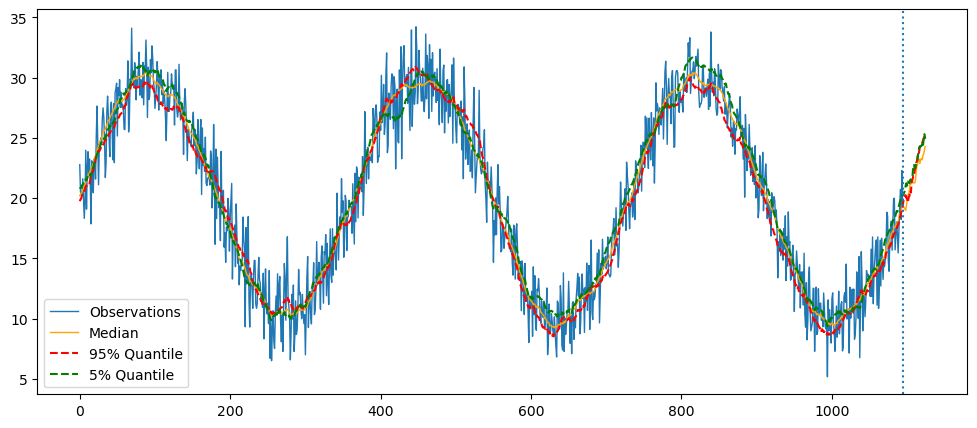

In [21]:
#visualize
plt.figure(figsize=(12,5))
plt.plot(np.arange(N), y, label="Observations", linewidth=1)
plt.plot(np.arange(N+H), np.concatenate([past_pred.mean(0), Y_pred.mean(0)]), label="Median", linewidth=1, color = 'orange')
plt.plot(np.arange(N+H), np.concatenate([past_pred_upp.mean(0), Y_pred_upp.mean(0)]), label="95% Quantile", linestyle='--', color = 'red')
plt.plot(np.arange(N+H), np.concatenate([past_pred_lower.mean(0), Y_pred_lower.mean(0)]), label="5% Quantile", linestyle='--', color = 'green')
plt.axvline(N, linestyle=':')
plt.legend()
plt.show()